## Mini Project: AI Grammar Checker by using NLP

#### Import Libraries

In [4]:
import spacy
from textblob import TextBlob
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pandas as pd


#### Input Text

In [5]:
text = "Apple is looking at buying U.K. startup for $1 billion. It want to expand their market."


#### Tokenization, POS, Chunking, NER (with spaCy)

In [6]:
nlp = spacy.load("en_core_web_sm")
doc = nlp(text)

# Tokenization
tokens = [token.text for token in doc]
print("Tokens:", tokens)

# POS Tagging
pos_tags = [(token.text, token.pos_) for token in doc]
print("\nPOS Tags:")
for word, tag in pos_tags:
    print(f"{word}: {tag}")

# Chunking (Noun Phrases)
print("\nChunks:")
for chunk in doc.noun_chunks:
    print(chunk.text)

# Named Entity Recognition (NER)
print("\nNamed Entities:")
for ent in doc.ents:
    print(f"{ent.text} --> {ent.label_}")


Tokens: ['Apple', 'is', 'looking', 'at', 'buying', 'U.K.', 'startup', 'for', '$', '1', 'billion', '.', 'It', 'want', 'to', 'expand', 'their', 'market', '.']

POS Tags:
Apple: PROPN
is: AUX
looking: VERB
at: ADP
buying: VERB
U.K.: PROPN
startup: VERB
for: ADP
$: SYM
1: NUM
billion: NUM
.: PUNCT
It: PRON
want: VERB
to: PART
expand: VERB
their: PRON
market: NOUN
.: PUNCT

Chunks:
Apple
U.K.
It
their market

Named Entities:
Apple --> ORG
U.K. --> GPE
$1 billion --> MONEY


#### Grammar Checking with TextBlob

In [7]:
blob = TextBlob(text)
corrected_text = blob.correct()

print("\nOriginal Text:")
print(text)
print("\nCorrected Text:")
print(corrected_text)



Original Text:
Apple is looking at buying U.K. startup for $1 billion. It want to expand their market.

Corrected Text:
Apple is looking at buying U.K. started for $1 billion. It want to expand their market.


#### TF-IDF Analysis

In [8]:
corpus = [
    text,
    str(corrected_text)
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

df_tfidf = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

print("\nTF-IDF DataFrame:")
print(df_tfidf)



TF-IDF DataFrame:
      apple        at   billion    buying    expand       for        is  \
0  0.258411  0.258411  0.258411  0.258411  0.258411  0.258411  0.258411   
1  0.258411  0.258411  0.258411  0.258411  0.258411  0.258411  0.258411   

         it   looking    market   started   startup     their        to  \
0  0.258411  0.258411  0.258411  0.000000  0.363188  0.258411  0.258411   
1  0.258411  0.258411  0.258411  0.363188  0.000000  0.258411  0.258411   

       want  
0  0.258411  
1  0.258411  


#### Visualization

#### WordCloud of Original Text

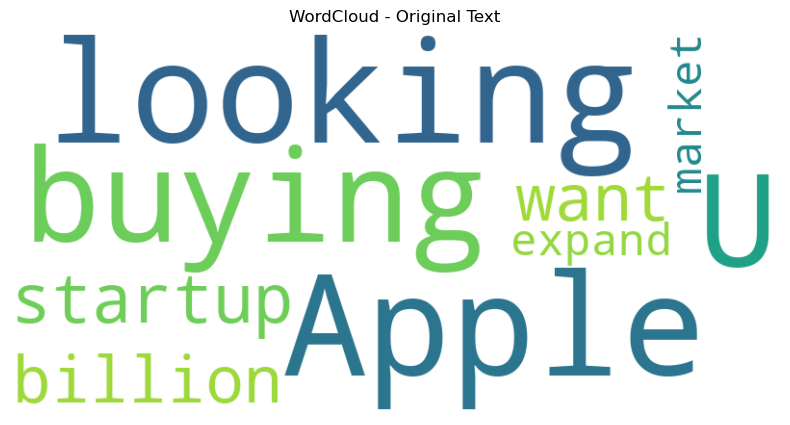

In [9]:
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud - Original Text")
plt.show()


#### POS Tag Distribution

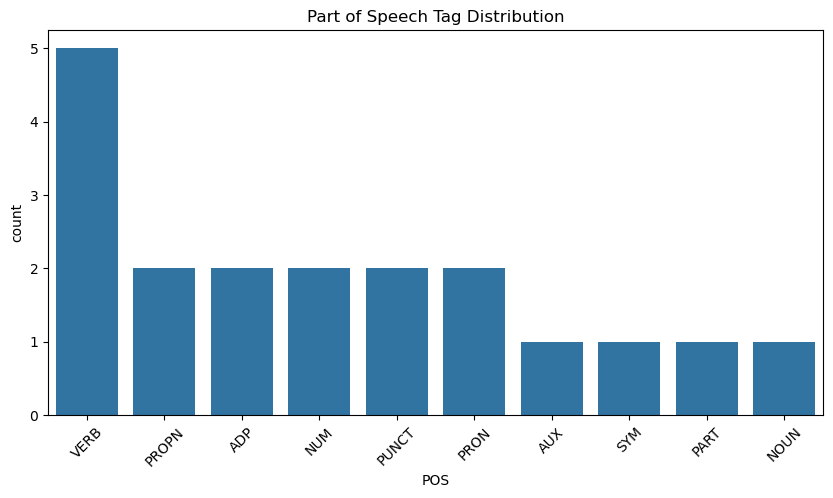

In [10]:
pos_df = pd.DataFrame(pos_tags, columns=["Token", "POS"])
plt.figure(figsize=(10, 5))
sns.countplot(data=pos_df, x='POS', order=pos_df['POS'].value_counts().index)
plt.title("Part of Speech Tag Distribution")
plt.xticks(rotation=45)
plt.show()


#### TF-IDF Bar Plot

C:\Users\NSTI\AppData\Local\Temp\ipykernel_14868\2302285214.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tfidf_plot.values, y=tfidf_plot.index, palette="viridis")


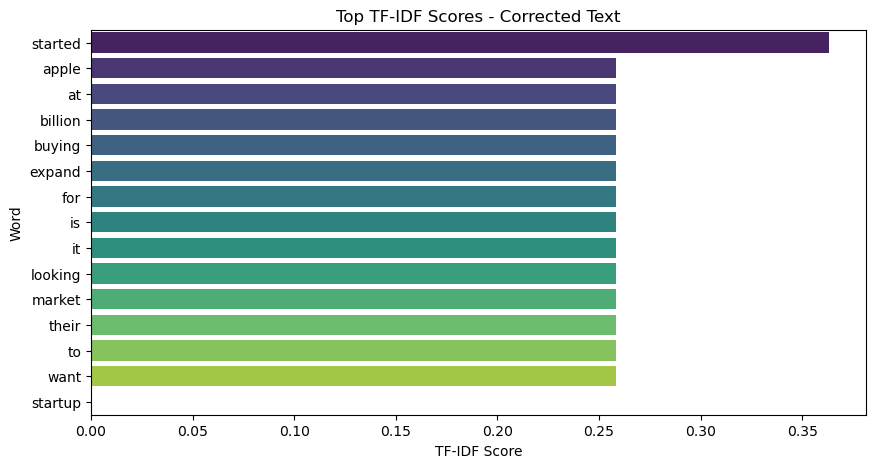

In [11]:
tfidf_plot = df_tfidf.iloc[1]  # Use corrected text
tfidf_plot = tfidf_plot.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=tfidf_plot.values, y=tfidf_plot.index, palette="viridis")
plt.title("Top TF-IDF Scores - Corrected Text")
plt.xlabel("TF-IDF Score")
plt.ylabel("Word")
plt.show()
